<a href="https://colab.research.google.com/github/sultaniqalbi/study_grup_ismile_2026/blob/main/Salinan_dari_Hari_2_Regresi_Linear_(Peserta).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hari 2: Regresi Linear
**Study Group I-Smile Lab: EDA to Machine Learning**
Jumat, 2 Oktober 2026 · Telkom University

### Tujuan hari ini
Setelah sesi ini kamu bisa:
1. Memisahkan fitur dan target, lalu membagi data menjadi data latih dan data uji beserta alasannya.
2. Melatih model regresi linear dengan satu fitur dan dengan semua fitur memakai scikit-learn.
3. Mengukur model dengan MAE, RMSE, dan R², lalu membandingkannya dengan baseline.
4. Membaca koefisien model dan mengenali batasan regresi linear.
5. Melihat sekilas bahwa model lain bisa jauh lebih akurat, dan memahami kenapa regresi linear tetap dipelajari.

### Alur sesi
| Waktu | Kegiatan | Isi notebook |
|---|---|---|
| Blok 1 (50 menit) | Dari data ke model | Bagian 0, Recall Hari 1, Bagian 1 sampai 4 |
| Break (10 menit) | Istirahat | |
| Blok 2 (50 menit) | Mengukur dan membandingkan model | Bagian 5 sampai 10 + penjelasan Tugas 2 |

### Cara pakai notebook ini
1. Di Colab, pilih **File → Simpan salinan di Drive** supaya perubahanmu tersimpan di Drive sendiri.
2. Cari sel bertanda `# TODO`, lalu ganti setiap `___` dengan kode yang tepat.
3. Jalankan sel **berurutan dari atas** dengan **Shift+Enter**. Kalau muncul error `NameError: name '...' is not defined`, berarti ada sel sebelumnya yang belum dijalankan (pakai menu *Runtime → Run before*).

Tanda yang dipakai di notebook ini:
- **Diskusi:** pertanyaan yang kita bahas bareng **sebelum** sel berikutnya dijalankan. Coba tebak dulu jawabannya.
- Blockquote **Di dunia nyata**: versi lanjutan yang dipakai di industri. Cukup dipahami, tidak perlu dipraktikkan.

## 0. Persiapan (± 3 menit)
Library hari ini: `pandas`, `numpy`, `matplotlib`, dan `scikit-learn` (`sklearn`) untuk membuat dan menilai model.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option("display.max_columns", None)  # tampilkan semua kolom saat print tabel
plt.rcParams["figure.figsize"] = (8, 4.5)

Ini data hasil cleaning Hari 1 (`df_final`), jadi kita tidak perlu membersihkan ulang dan bisa langsung membuat model.

In [16]:
# Lokasi dataset. Di Colab, ganti dengan link Google Drive, misalnya:
# DATA_PATH = "https://drive.google.com/uc?id=ISI_ID_FILE_DI_SINI"
DATA_PATH = "housing_clean.csv"

df = pd.read_csv(DATA_PATH)
assert df.shape == (20640, 13), f"Ukuran data {df.shape}, seharusnya (20640, 13). Cek lagi file-nya."
print("Ukuran data (baris, kolom):", df.shape)
df.head()

Ukuran data (baris, kolom): (20640, 13)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,0,0,1,0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,0,0,1,0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,0,0,1,0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,0,0,1,0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,0,0,1,0


---
# Blok 1: Dari data ke model (± 50 menit)

## Recall Hari 1 (± 7 menit)

**Diskusi:** Data ini sudah bersih. Coba ingat: tahapan apa saja yang kita lakukan di Hari 1 sampai data jadi seperti ini? Mulai dari EDA, pakai cara apa saja? Lalu di data cleaning, masalah apa saja yang ditangani dan bagaimana caranya?

### Jawaban kelompok
**EDA:**
1. \_\_\_
2. \_\_\_
3. \_\_\_
4. ...

**Data Cleaning:**
1. \_\_\_
2. \_\_\_
3. \_\_\_
4. ...

Sekarang buktikan bahwa data ini memang sudah bersih:

In [17]:
print("Total missing value :", df.isnull().sum().sum())
print("Total baris duplikat:", df.duplicated().sum())
print()
print(df.dtypes)

Total missing value : 0
Total baris duplikat: 0

longitude                     float64
latitude                      float64
housing_median_age            float64
total_rooms                   float64
total_bedrooms                float64
population                    float64
households                    float64
median_income                 float64
median_house_value            float64
ocean_proximity_INLAND          int64
ocean_proximity_ISLAND          int64
ocean_proximity_NEAR BAY        int64
ocean_proximity_NEAR OCEAN      int64
dtype: object


**Diskusi:** Dari output ini, langkah cleaning mana yang kelihatan hasilnya?

> **Di dunia nyata (cukup dipahami, tidak dipraktikkan):** Nilai median untuk `fillna` seharusnya dihitung dari data latih saja, setelah split, supaya data uji tidak "mengintip". Di Hari 1 disederhanakan karena dampaknya sangat kecil.

## 1. Fitur dan target (± 5 menit)
- **Fitur (`X`)**: kolom-kolom yang dipakai untuk **menebak**. Ibaratnya soal ujian.
- **Target (`y`)**: kolom yang mau **ditebak**, yaitu `median_house_value`. Ibaratnya kunci jawaban.

`X` ditulis huruf besar karena berupa tabel (banyak kolom), sedangkan `y` huruf kecil karena hanya satu kolom. Target **wajib dikeluarkan** dari `X`. Kalau tidak, model sama saja menyontek kunci jawaban.

In [19]:
# TODO: pisahkan fitur (X) dan target (y). Target kita adalah median_house_value
X = df.drop(columns="median_house_value")
y = df["median_house_value"]

print("Ukuran X:", X.shape)
print("Ukuran y:", y.shape)

Ukuran X: (20640, 12)
Ukuran y: (20640,)


## 2. Train-test split (± 10 menit)
Model harus dinilai pakai data yang **belum pernah dilihatnya**, sama seperti ujian yang soalnya berbeda dari soal latihan. Karena itu data dibagi dua:
- **Data latih (train), 80%**: dipakai model untuk belajar.
- **Data uji (test), 20%**: disimpan dulu, baru dipakai di akhir untuk menilai model.

Fungsi `train_test_split` mengacak baris lalu membaginya. `random_state` mengunci cara mengacaknya supaya hasilnya sama setiap kali dijalankan.

In [50]:
# TODO: bagi data menjadi 80% data latih dan 20% data uji, dengan random_state=42
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train:", X_train.shape, "| X_test:", X_test.shape)
print("y_train:", y_train.shape, "| y_test:", y_test.shape)

X_train: (16512, 12) | X_test: (4128, 12)
y_train: (16512,) | y_test: (4128,)


Perhatikan urutan hasilnya: `X_train, X_test, y_train, y_test`. Kalau urutannya tertukar, error baru muncul di langkah berikutnya.

**Diskusi:** (1) Kenapa model tidak dinilai pakai data latih saja? (2) Apa jadinya kalau `random_state` dihapus lalu sel ini dijalankan dua kali?

**Sambungan ke Hari 1:** inilah alasan duplikat dibuang. Kalau satu baris punya kembaran, bisa saja yang satu masuk data latih dan kembarannya masuk data uji. Model jadi "sudah pernah melihat soal ujiannya", dan nilainya terlihat lebih bagus daripada kenyataan.

> **Di dunia nyata (cukup dipahami, tidak dipraktikkan):** Data yang berurutan waktu (misalnya penjualan harian) tidak di-split acak. Data lama dipakai untuk latih, data terbaru untuk uji. Untuk target yang tidak seimbang (misalnya 95% "tidak churn"), dipakai `stratify` supaya proporsinya sama di train dan test. Model akhir juga dipilih memakai *validation set* atau *cross-validation*, bukan data uji. Ini materi Hari 4.

## 3. Regresi linear sederhana: satu fitur (± 15 menit)
Kita mulai dari satu fitur saja: `median_income`, fitur dengan korelasi tertinggi terhadap harga di Hari 1 (± 0,69).

Regresi linear mencari **garis lurus terbaik**:

harga = intercept + koefisien × median_income

"Terbaik" artinya total kuadrat jarak antara titik data dan garis sekecil mungkin. Proses mencari garis ini disebut `fit` (melatih), dan hanya memakai **data latih**.

**Penting:** scikit-learn meminta fitur dalam bentuk **tabel (2 dimensi)**, walaupun isinya cuma satu kolom:
- `X_train[["median_income"]]` dengan kurung siku dua menghasilkan DataFrame (tabel 1 kolom). Ini **benar**.
- `X_train["median_income"]` dengan kurung siku satu menghasilkan Series (1 dimensi). Ini akan **error**.

In [65]:
# TODO: latih model regresi linear dengan satu fitur (median_income) memakai data latih
model_1 = LinearRegression()
model_1.fit( X_train[["median_income"]], y_train)

LinearRegression()

In [70]:
# TODO: tebak harga untuk data uji. Pakai kolom yang sama persis seperti saat fit
pred_1 = model_1.predict(X_test[["median_income"]])
pred_1[:5].round(0)

array([115216., 173417., 178920., 284698., 256475.])

Lihat garis yang ditemukan model, digambar di atas data uji:

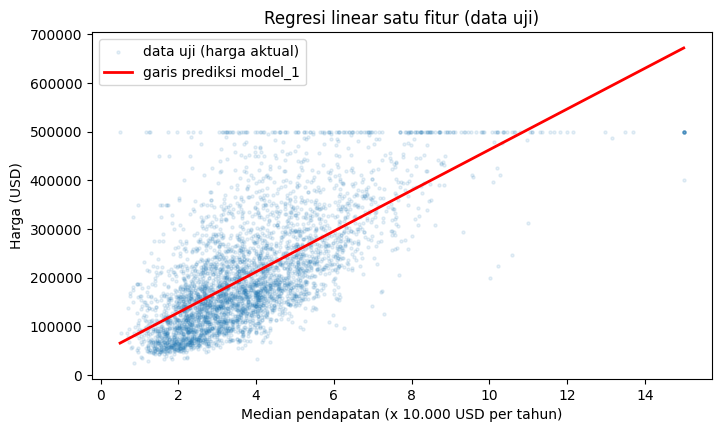

In [71]:
# Garis prediksi: 100 titik income dari minimum sampai maksimum, lalu ditebak oleh model
x_garis = pd.DataFrame({"median_income": np.linspace(X_test["median_income"].min(), X_test["median_income"].max(), 100)})
y_garis = model_1.predict(x_garis)

plt.scatter(X_test["median_income"], y_test, alpha=0.1, s=5, label="data uji (harga aktual)")
plt.plot(x_garis["median_income"], y_garis, color="red", linewidth=2, label="garis prediksi model_1")
plt.title("Regresi linear satu fitur (data uji)")
plt.xlabel("Median pendapatan (x 10.000 USD per tahun)")
plt.ylabel("Harga (USD)")
plt.legend()
plt.show()

**Diskusi:** Garisnya cocok di bagian mana, dan meleset di bagian mana?

## 4. Membaca koefisien dan intercept (± 10 menit)
Setelah `fit`, garis yang ditemukan model disimpan di dua atribut:
- `coef_` adalah **koefisien**, yaitu kemiringan garis: seberapa besar harga berubah kalau income naik 1 unit.
- `intercept_` adalah **titik potong**, yaitu harga tebakan saat income = 0.

Garis bawah (`_`) di akhir nama menandakan nilai yang baru ada **setelah** model di-`fit`.

In [72]:
# TODO: tampilkan koefisien dan intercept model_1
print("Koefisien:", model_1.coef_)
print("Intercept:", model_1.intercept_)

Koefisien: [41781.47656924]
Intercept: 44972.67985077211


In [75]:
koef_1 = model_1.coef_[0]          # coef_ berupa array, ambil elemen pertama
intercept_1 = model_1.intercept_

print(f"Rumus garis: harga = {intercept_1:,.0f} + {koef_1:,.0f} x median_income")

Rumus garis: harga = 44,973 + 41,781 x median_income


Coba buktikan bahwa `predict` sebenarnya hanya menghitung rumus itu. Contoh: blok dengan `median_income` = 5 (pendapatan 50 ribu USD per tahun).

*Catatan: di output kode, pemisah ribuan memakai koma (gaya Python), jadi 41,781 artinya 41.781.*

In [76]:
income_contoh = 5
hitung_manual = intercept_1 + koef_1 * income_contoh
hitung_model = model_1.predict(pd.DataFrame({"median_income": [income_contoh]}))[0]

print(f"Hitung manual dengan rumus: USD {hitung_manual:,.0f}")
print(f"Hasil model_1.predict     : USD {hitung_model:,.0f}")

Hitung manual dengan rumus: USD 253,880
Hasil model_1.predict     : USD 253,880


**Cara membaca koefisien:** setiap kenaikan 1 unit `median_income` (= 10.000 USD pendapatan per tahun), harga rumah naik sekitar **USD 41.800**.

**Diskusi:** Intercept artinya apa? Masuk akal tidak?

---
# Break (10 menit)
Istirahat dulu. Pastikan semua sel di atas sudah jalan tanpa error sebelum lanjut.

---

# Blok 2: Mengukur dan membandingkan model (± 50 menit)

## 5. Metrik evaluasi (± 16 menit)
### Residual (error)
Untuk setiap blok di data uji, kita bisa menghitung seberapa meleset tebakannya:

**error = harga aktual − harga prediksi**

Error positif berarti model menebak terlalu **rendah**, sedangkan error negatif berarti terlalu **tinggi**.

In [77]:
contoh_error = pd.DataFrame({
    "aktual": y_test.values[:5],
    "prediksi": pred_1[:5].round(0),
})
contoh_error["error"] = contoh_error["aktual"] - contoh_error["prediksi"]
contoh_error

,aktual,prediksi,error
0,47700.0,115216.0,-67516.0
1,57900.0,173417.0,-115517.0
2,500001.0,178920.0,321081.0
3,218600.0,284698.0,-66098.0
4,386500.0,256475.0,130025.0


Kita punya 4.128 error, satu per blok di data uji. Supaya bisa menilai dan membandingkan model, ribuan error itu perlu diringkas menjadi **satu angka**. Itulah gunanya metrik.

### Baseline: pembanding paling sederhana
Sebelum memuji model, bandingkan dulu dengan model "bodoh" yang **selalu menebak rata-rata harga data latih** untuk semua blok, tanpa melihat fitur apa pun. Model baru dianggap berguna kalau **lebih baik dari baseline**.

In [78]:
rata_train = y_train.mean()
pred_baseline = np.full(len(y_test), rata_train)   # tebakan yang sama untuk semua blok

print(f"Baseline selalu menebak: USD {rata_train:,.0f}")

Baseline selalu menebak: USD 207,127


### MAE (Mean Absolute Error)
$$\text{MAE} = \frac{1}{n}\sum_{i=1}^{n}|y_i - \hat{y}_i|$$

Dalam bahasa awam: **rata-rata seberapa jauh tebakan meleset**, dalam USD. Tanda mutlak membuat meleset ke atas dan ke bawah sama-sama dihitung positif.

In [83]:
# TODO: hitung MAE model_1. Format: mean_absolute_error(harga_aktual, harga_prediksi)
mae_baseline = mean_absolute_error(y_test, pred_baseline)
mae_1 = mean_absolute_error(y_test, pred_1)

print(f"MAE baseline: USD {mae_baseline:,.0f}")
print(f"MAE model_1 : USD {mae_1:,.0f}")

MAE baseline: USD 90,437
MAE model_1 : USD 62,824


### RMSE (Root Mean Squared Error)
$$\text{RMSE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}$$

Dalam bahasa awam: mirip MAE (juga dalam USD), tapi error **dikuadratkan dulu**, sehingga tebakan yang meleset jauh dihukum lebih berat. Fungsi `mean_squared_error` menghasilkan rata-rata kuadratnya (MSE), jadi kita perlu mengambil akarnya.

In [84]:
# TODO: hitung RMSE model_1 = akar dari mean_squared_error
rmse_baseline = np.sqrt(mean_squared_error(y_test, pred_baseline))
rmse_1 = np.sqrt(mean_squared_error(y_test, pred_1))

print(f"RMSE baseline: USD {rmse_baseline:,.0f}")
print(f"RMSE model_1 : USD {rmse_1:,.0f}")

RMSE baseline: USD 114,150
RMSE model_1 : USD 83,808


### R² (koefisien determinasi)
$$R^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}$$

Dalam bahasa awam: **seberapa besar bagian naik-turunnya harga yang berhasil dijelaskan model**, dibandingkan dengan sekadar menebak rata-rata. R² tidak punya satuan. Nilai 0 berarti setara baseline, 1 berarti sempurna, dan nilai negatif berarti lebih buruk daripada baseline.

In [85]:
# TODO: hitung R² model_1. Urutan argumen penting: (harga_aktual, harga_prediksi)
r2_baseline = r2_score(y_test, pred_baseline)
r2_1 = r2_score(y_test, pred_1)

print(f"R² baseline: {r2_baseline:.3f}")
print(f"R² model_1 : {r2_1:.3f}")

R² baseline: -0.000
R² model_1 : 0.461


**Diskusi:** Kenapa RMSE selalu lebih besar atau sama dengan MAE? Kapan selisih keduanya besar?

> **Di dunia nyata (cukup dipahami, tidak dipraktikkan):** Metrik dipilih sesuai kebutuhan bisnis. Kalau meleset USD 20.000 pada rumah seharga USD 60.000 dianggap jauh lebih parah daripada meleset sebesar itu pada rumah seharga USD 600.000, tim data memakai metrik persentase seperti MAPE. Kalau beberapa tebakan yang meleset jauh sangat merugikan, RMSE yang dijadikan patokan.

## 6. Regresi linear berganda: semua fitur (± 10 menit)
Sekarang semua 12 fitur dipakai sekaligus. Rumusnya tetap garis (lebih tepatnya bidang) lurus, hanya saja suku koefisiennya lebih banyak:

harga = intercept + koef₁ × fitur₁ + koef₂ × fitur₂ + ... + koef₁₂ × fitur₁₂

In [105]:
# TODO: latih model dengan SEMUA fitur, lalu tebak harga data uji
model_semua = LinearRegression()
model_semua.fit(X_train,y_train)
pred_semua = model_semua.predict(X_test)

In [115]:
# TODO: hitung tiga metrik untuk model_semua. Prediksi mana yang dinilai?
mae_semua = mean_absolute_error(y_test, pred_semua)
rmse_semua = np.sqrt(mean_squared_error(y_test, pred_semua))
r2_semua = r2_score(y_test, pred_semua)

print(f"model_semua -> MAE: USD {mae_semua:,.0f} | RMSE: USD {rmse_semua:,.0f} | R²: {r2_semua:.3f}")

model_semua -> MAE: USD 50,394 | RMSE: USD 69,350 | R²: 0.631


Bandingkan ketiga model dalam satu tabel:

In [116]:
perbandingan = pd.DataFrame({
    "model": ["Baseline (rata-rata)", "1 fitur (median_income)", "Semua fitur (12)"],
    "MAE": [mae_baseline, mae_1, mae_semua],
    "RMSE": [rmse_baseline, rmse_1, rmse_semua],
    "R²": [r2_baseline, r2_1, r2_semua],
})
perbandingan.style.format({"MAE": "{:,.0f}", "RMSE": "{:,.0f}", "R²": "{:.3f}"}).hide(axis="index")

model,MAE,RMSE,R²
Baseline (rata-rata),"90,437","114,150",-0.000
1 fitur (median_income),"62,824","83,808",0.461
Semua fitur (12),"50,394","69,350",0.631


**Diskusi:** Fitur bertambah dari 1 menjadi 12, R² naik berapa? Sepadan tidak?

## 7. Membaca koefisien model berganda (± 10 menit)
Setiap fitur sekarang punya koefisien sendiri:

In [117]:
koefisien = pd.DataFrame({
    "fitur": X_train.columns,
    "koefisien": model_semua.coef_,
}).sort_values("koefisien", ascending=False)

koefisien.style.format({"koefisien": "{:,.1f}"}).hide(axis="index")

fitur,koefisien
ocean_proximity_ISLAND,"173,331.6"
median_income,"38,877.7"
ocean_proximity_NEAR OCEAN,"5,154.7"
housing_median_age,"1,056.0"
households,83.8
total_bedrooms,67.9
total_rooms,-4.9
population,-39.7
ocean_proximity_NEAR BAY,"-3,290.1"
latitude,"-25,172.9"


**Cara baca:** dengan **fitur lain tetap**, kenaikan 1 unit fitur X mengubah harga sebesar koefisiennya. Contohnya `median_income`: dua blok yang semua kolom lainnya sama persis, tetapi income-nya beda 1 unit (10.000 USD), harga tebakannya berbeda sebesar koefisien `median_income`.

**Kolom dummy dibaca relatif terhadap kategori yang di-drop.** Di Hari 1, `drop_first=True` membuang kategori `<1H OCEAN`. Karena itu koefisien `ocean_proximity_INLAND` (sekitar −39 ribu) dibaca: *blok INLAND rata-rata sekitar USD 39.000 lebih murah dibandingkan blok `<1H OCEAN` dengan kondisi lain yang sama.*

**Diskusi:** (1) Di Hari 1, `total_rooms` berkorelasi **positif** dengan harga (± 0,13). Kenapa koefisiennya **negatif** di sini? Petunjuk: lihat tabel korelasi di bawah.

In [118]:
kolom_ukuran_blok = ["total_rooms", "total_bedrooms", "population", "households"]
df[kolom_ukuran_blok].corr().round(2)

,total_rooms,total_bedrooms,population,households
total_rooms,1.00,0.93,0.86,0.92
total_bedrooms,0.93,1.00,0.87,0.97
population,0.86,0.87,1.00,0.91
households,0.92,0.97,0.91,1.00


**Diskusi:** (2) Koefisien `ocean_proximity_ISLAND` paling besar. Bisa dipercaya? Cek berapa baris ISLAND yang dipakai model untuk belajar:

In [119]:
print("Baris ISLAND di data latih:", X_train["ocean_proximity_ISLAND"].sum())
print("Baris ISLAND di data uji  :", X_test["ocean_proximity_ISLAND"].sum())

Baris ISLAND di data latih: 4
Baris ISLAND di data uji  : 1


**Diskusi:** (3) Bisakah kita bilang `median_income` lebih penting daripada `population` hanya karena angka koefisiennya jauh lebih besar?

> **Di dunia nyata (cukup dipahami, tidak dipraktikkan):** Multikolinearitas dicek dengan VIF (*Variance Inflation Factor*). Besar pengaruh antar fitur dibandingkan memakai koefisien dari fitur yang sudah di-scaling. Apakah sebuah koefisien "sungguhan" atau hanya kebetulan dilihat dari p-value, misalnya dengan library `statsmodels`.

## 8. Prediksi vs aktual (± 8 menit)
Kalau model sempurna, semua titik akan berada tepat di garis merah (prediksi = aktual).

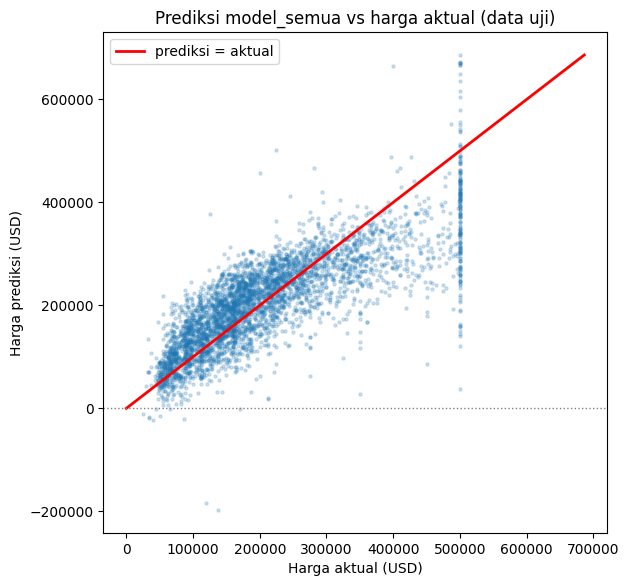

In [120]:
plt.figure(figsize=(6.5, 6.5))
plt.scatter(y_test, pred_semua, alpha=0.2, s=5)
batas = [0, max(y_test.max(), pred_semua.max())]   # garis diagonal dari harga 0 sampai harga tertinggi
plt.plot(batas, batas, color="red", linewidth=2, label="prediksi = aktual")
plt.axhline(0, color="gray", linestyle=":", linewidth=1)
plt.title("Prediksi model_semua vs harga aktual (data uji)")
plt.xlabel("Harga aktual (USD)")
plt.ylabel("Harga prediksi (USD)")
plt.legend()
plt.show()

In [123]:
# TODO: hitung berapa prediksi yang bernilai negatif (harga di bawah 0)
jumlah_negatif = (pred_semua < 0).sum()
jumlah_di_atas_cap = (pred_semua > 500001).sum()

print("Prediksi negatif         :", jumlah_negatif)
print("Prediksi di atas 500.001 :", jumlah_di_atas_cap)
print("y_test tepat 500.001     :", (y_test == 500001).sum())

Prediksi negatif         : 11
Prediksi di atas 500.001 : 23
y_test tepat 500.001     : 164


**Diskusi:** (1) Harga rumah negatif, kenapa bisa? (2) Kenapa ada barisan titik **vertikal** di ujung kanan grafik?

> **Di dunia nyata (cukup dipahami, tidak dipraktikkan):** Target yang miring ke kanan seperti harga sering ditransformasi log dulu, yaitu model menebak log(harga) lalu hasilnya dikembalikan, sehingga prediksinya tidak bisa negatif. Data yang di-capping dibuang atau ditangani dengan model khusus. Model non-linear seperti decision tree atau random forest juga dicoba sebagai pembanding, karena bisa menangkap pola yang tidak lurus, seperti pola lokasi di peta Hari 1. Salah satunya akan kita lihat sekilas di Bagian 9.

## 9. Sekilas: model lain (± 4 menit)
Regresi linear bukan satu-satunya model. Kita coba satu model lain dengan data dan split yang sama. Cara kerjanya dibahas di Hari 4, hari ini cukup lihat hasilnya.

In [124]:
# Demonstrasi: Random Forest. Proses fit butuh sekitar 10-15 detik di Colab, tunggu sampai selesai.
model_rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model_rf.fit(X_train, y_train)
pred_rf = model_rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, pred_rf))
r2_rf = r2_score(y_test, pred_rf)

print(f"Random Forest -> MAE: USD {mae_rf:,.0f} | RMSE: USD {rmse_rf:,.0f} | R²: {r2_rf:.3f}")

Random Forest -> MAE: USD 32,128 | RMSE: USD 49,552 | R²: 0.812


In [125]:
perbandingan_akhir = pd.DataFrame({
    "model": ["Baseline (rata-rata)", "Linear 1 fitur (median_income)", "Linear semua fitur (12)", "Random Forest (12 fitur)"],
    "MAE": [mae_baseline, mae_1, mae_semua, mae_rf],
    "RMSE": [rmse_baseline, rmse_1, rmse_semua, rmse_rf],
    "R²": [r2_baseline, r2_1, r2_semua, r2_rf],
})
perbandingan_akhir.style.format({"MAE": "{:,.0f}", "RMSE": "{:,.0f}", "R²": "{:.3f}"}).hide(axis="index")

model,MAE,RMSE,R²
Baseline (rata-rata),"90,437","114,150",-0.000
Linear 1 fitur (median_income),"62,824","83,808",0.461
Linear semua fitur (12),"50,394","69,350",0.631
Random Forest (12 fitur),"32,128","49,552",0.812


**Diskusi:** R² naik jauh. Lalu kenapa kita tetap belajar regresi linear?

## 10. Ringkasan (± 2 menit)
| Langkah | Kode | Tujuannya |
|---|---|---|
| Split | `train_test_split(X, y, test_size=0.2, random_state=42)` | Menyisihkan data uji yang tidak dilihat model |
| Fit | `model.fit(X_train, y_train)` | Model belajar garis terbaik dari data latih |
| Predict | `model.predict(X_test)` | Model menebak harga data uji |
| Evaluasi | `mean_absolute_error`, `np.sqrt(mean_squared_error)`, `r2_score` | Mengukur seberapa meleset, dibandingkan dengan baseline |
| Interpretasi | `model.coef_`, `model.intercept_` | Membaca apa yang dipelajari model, beserta batasannya |

**Berikutnya:**
- **Hari 3**: dataset baru dan **klasifikasi** (menebak kategori, bukan angka), plus **scaling** supaya fitur dengan satuan berbeda bisa dibandingkan secara adil (ingat Diskusi 3 di Bagian 7).
- **Hari 4**: membandingkan skor **train vs test** dan mengenali **overfitting**, yaitu model yang hafal data latih tapi gagal di data baru. Hari 4 juga membahas kenapa Random Forest lebih baik, dan cara membandingkan model dengan adil.